In [17]:
## 1. import / 경로 설정 / CSV 로드
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path(r"C:\취준\olist-ecommerce-analysis")

OUTPUT_DIR = PROJECT_DIR / "outputs"
IMAGE_DIR = PROJECT_DIR / "images"

IMAGE_DIR.mkdir(exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("IMAGE_DIR:", IMAGE_DIR)

monthly_kpi = pd.read_csv(OUTPUT_DIR / "monthly_kpi.csv")
category_revenue_top10 = pd.read_csv(OUTPUT_DIR / "category_revenue_top10.csv")
category_revenue_share = pd.read_csv(OUTPUT_DIR / "category_revenue_share.csv")
delivery_delay_by_state = pd.read_csv(OUTPUT_DIR / "delivery_delay_by_state.csv")
review_score_by_delay_group = pd.read_csv(OUTPUT_DIR / "review_score_by_delay_group.csv")

print("monthly_kpi:", monthly_kpi.shape)
print("category_revenue_top10:", category_revenue_top10.shape)
print("category_revenue_share:", category_revenue_share.shape)
print("delivery_delay_by_state:", delivery_delay_by_state.shape)
print("review_score_by_delay_group:", review_score_by_delay_group.shape)

PROJECT_DIR: C:\취준\olist-ecommerce-analysis
OUTPUT_DIR: C:\취준\olist-ecommerce-analysis\outputs
IMAGE_DIR: C:\취준\olist-ecommerce-analysis\images
monthly_kpi: (23, 8)
category_revenue_top10: (10, 7)
category_revenue_share: (20, 7)
delivery_delay_by_state: (24, 7)
review_score_by_delay_group: (5, 7)


In [18]:
## 2. 시각화 공통 설정 / 데이터 전처리
# 한글 폰트 설정
# Windows 기준: Malgun Gothic
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 이미지 저장 시 해상도
DPI = 150

# 월별 KPI는 초기 데이터 구간을 제외하고 2017-01 ~ 2018-08 중심으로 시각화
monthly_kpi_viz = monthly_kpi[
    (monthly_kpi["purchase_month"] >= "2017-01") &
    (monthly_kpi["purchase_month"] <= "2018-08")
].copy()

monthly_kpi_viz["purchase_month"] = pd.to_datetime(
    monthly_kpi_viz["purchase_month"]
)

# 카테고리 매출 TOP10은 보기 좋게 오름차순 정렬해서 horizontal bar에 사용
category_top10_viz = category_revenue_top10.sort_values(
    "revenue",
    ascending=True
).copy()

# 지역별 배송 지연율 TOP10
delay_state_top10_viz = delivery_delay_by_state.sort_values(
    "delayed_order_rate_pct",
    ascending=False
).head(10).sort_values(
    "delayed_order_rate_pct",
    ascending=True
).copy()

# 배송 지연 구간 순서 정리
delay_group_order = [
    "early_7plus_days",
    "early_1_to_6_days",
    "delayed_1_to_3_days",
    "delayed_4_to_7_days",
    "delayed_8plus_days"
]

review_delay_viz = review_score_by_delay_group[
    review_score_by_delay_group["delay_group"].isin(delay_group_order)
].copy()

review_delay_viz["delay_group"] = pd.Categorical(
    review_delay_viz["delay_group"],
    categories=delay_group_order,
    ordered=True
)

review_delay_viz = review_delay_viz.sort_values("delay_group")

# 그래프에 표시할 한글 라벨
delay_group_label_map = {
    "early_7plus_days": "7일 이상 조기 도착",
    "early_1_to_6_days": "1~6일 조기 도착",
    "delayed_1_to_3_days": "1~3일 지연",
    "delayed_4_to_7_days": "4~7일 지연",
    "delayed_8plus_days": "8일 이상 지연"
}

review_delay_viz["delay_group_label"] = review_delay_viz["delay_group"].map(
    delay_group_label_map
)

display(monthly_kpi_viz.head())
display(category_top10_viz.head())
display(delay_state_top10_viz.head())
display(review_delay_viz)

,purchase_month,order_count,customer_count,revenue,avg_order_value,avg_delivery_days,delayed_order_rate_pct,avg_review_score
3,2017-01-01,750,718,127545.67,170.06,12.65,3.07,4.20
4,2017-02-01,1653,1630,271298.65,164.13,13.17,3.21,4.20
5,2017-03-01,2546,2508,414369.39,162.75,12.95,5.58,4.19
6,2017-04-01,2303,2274,390952.18,169.76,14.92,7.86,4.14
7,2017-05-01,3546,3479,567066.73,159.92,11.32,3.61,4.24


,product_category,order_count,item_count,revenue,freight_revenue,avg_item_price,avg_review_score
9,toys,3804,4030,471286.48,75774.58,116.94,4.21
8,auto,3810,4140,578966.65,90488.10,139.85,4.12
7,cool_stuff,3559,3718,610204.10,81476.79,164.12,4.19
6,housewares,5743,6795,615628.69,142763.56,90.60,4.11
5,furniture_decor,6307,8160,711927.69,168402.23,87.25,3.95


,customer_state,order_count,avg_delivery_days,avg_delay_days,delayed_order_count,delayed_order_rate_pct,avg_review_score
9,ES,1995,15.79,-9.80,244,12.23,4.08
8,PA,946,23.77,-13.39,117,12.37,3.91
7,TO,274,17.66,-11.44,35,12.77,4.15
6,RJ,12350,15.31,-11.05,1664,13.47,3.97
5,BA,3256,19.34,-10.10,457,14.04,3.93


,delay_group_order,delay_group,order_count,avg_delay_days,avg_review_score,low_score_rate_pct,five_star_rate_pct,delay_group_label
0,1,early_7plus_days,70929,-15.16,4.32,8.94,63.58,7일 이상 조기 도착
1,2,early_1_to_6_days,17234,-4.16,4.20,10.21,57.43,1~6일 조기 도착
2,4,delayed_1_to_3_days,2636,1.40,3.77,19.08,43.13,1~3일 지연
3,5,delayed_4_to_7_days,1773,5.11,2.32,61.25,18.10,4~7일 지연
4,6,delayed_8plus_days,3252,18.33,1.73,78.32,7.47,8일 이상 지연


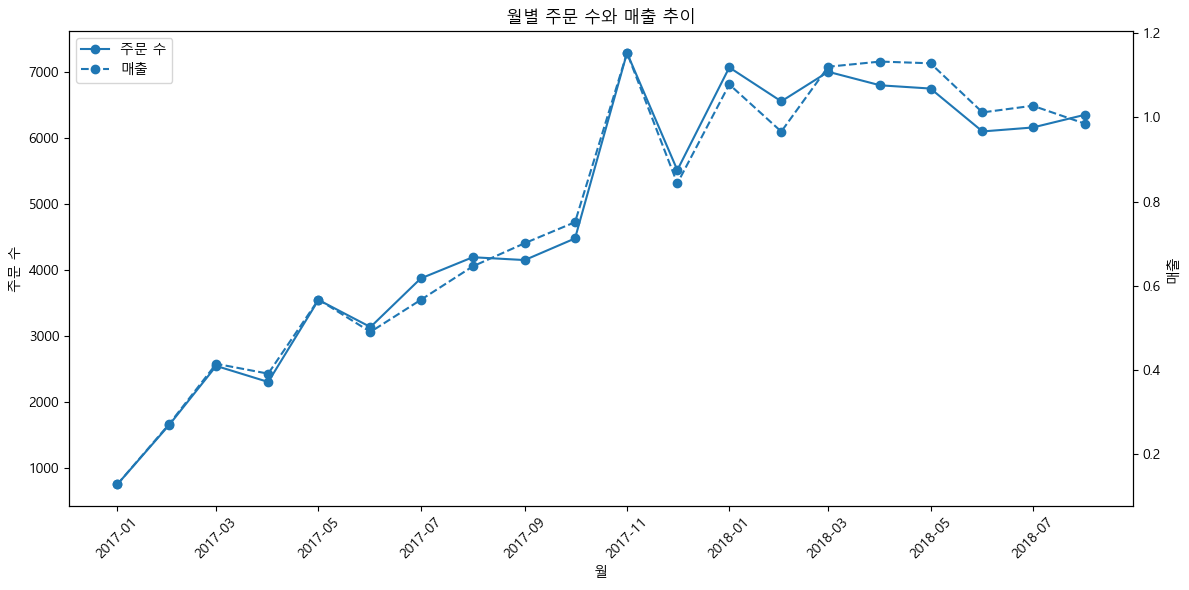

In [19]:
## 3. 포트폴리오용 시각화 5장 생성 및 저장
# 3-1. 월별 주문 수·매출 추이
# 매출은 백만 단위로 변환해 축의 1e6 표시를 제거한다.

monthly_kpi_viz["revenue_million"] = monthly_kpi_viz["revenue"] / 1_000_000

fig, ax1 = plt.subplots(figsize=(12, 6))

# 주문 수
ax1.plot(
    monthly_kpi_viz["purchase_month"],
    monthly_kpi_viz["order_count"],
    marker="o",
    label="주문 수"
)

ax1.set_xlabel("월")
ax1.set_ylabel("주문 수")
ax1.tick_params(axis="x", rotation=45)

# 매출
ax2 = ax1.twinx()

ax2.plot(
    monthly_kpi_viz["purchase_month"],
    monthly_kpi_viz["revenue_million"],
    marker="o",
    linestyle="--",
    label="매출"
)

ax2.set_ylabel("매출")

plt.title("월별 주문 수와 매출 추이")

# 범례 통합
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.savefig(
    IMAGE_DIR / "01_monthly_orders_revenue.png",
    dpi=DPI,
    bbox_inches="tight"
)
plt.show()

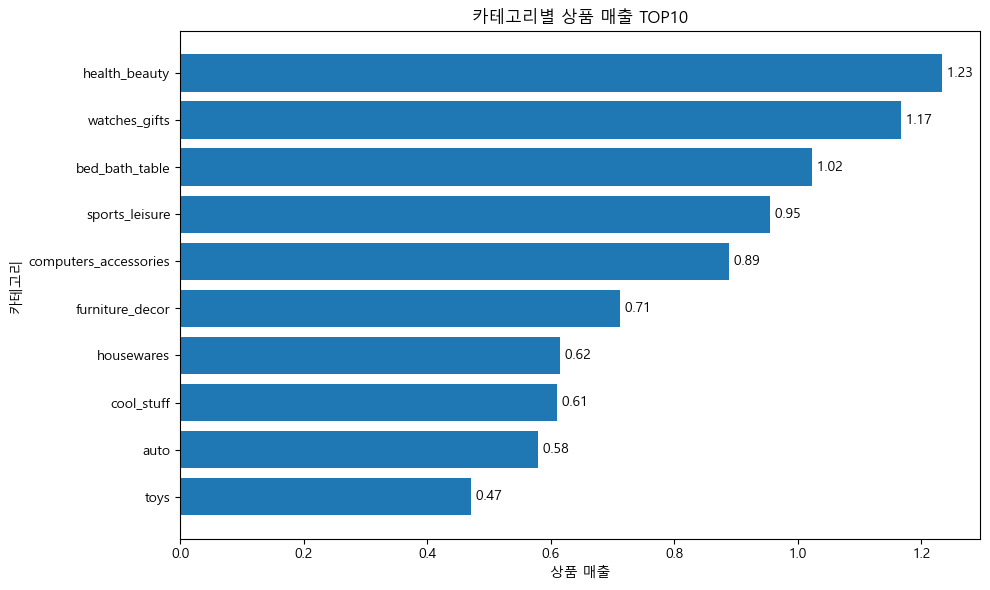

In [20]:
## 3. 포트폴리오용 시각화 5장 생성 및 저장
# 3-2. 카테고리별 상품 매출 TOP10
# 상품 매출은 백만 단위로 변환해 축의 1e6 표시를 제거한다.

category_top10_viz["revenue_million"] = category_top10_viz["revenue"] / 1_000_000

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    category_top10_viz["product_category"],
    category_top10_viz["revenue_million"]
)

ax.set_title("카테고리별 상품 매출 TOP10")
ax.set_xlabel("상품 매출")
ax.set_ylabel("카테고리")

for i, value in enumerate(category_top10_viz["revenue_million"]):
    ax.text(
        value,
        i,
        f" {value:.2f}",
        va="center"
    )

plt.tight_layout()
plt.savefig(
    IMAGE_DIR / "02_top_categories_revenue.png",
    dpi=DPI,
    bbox_inches="tight"
)
plt.show()

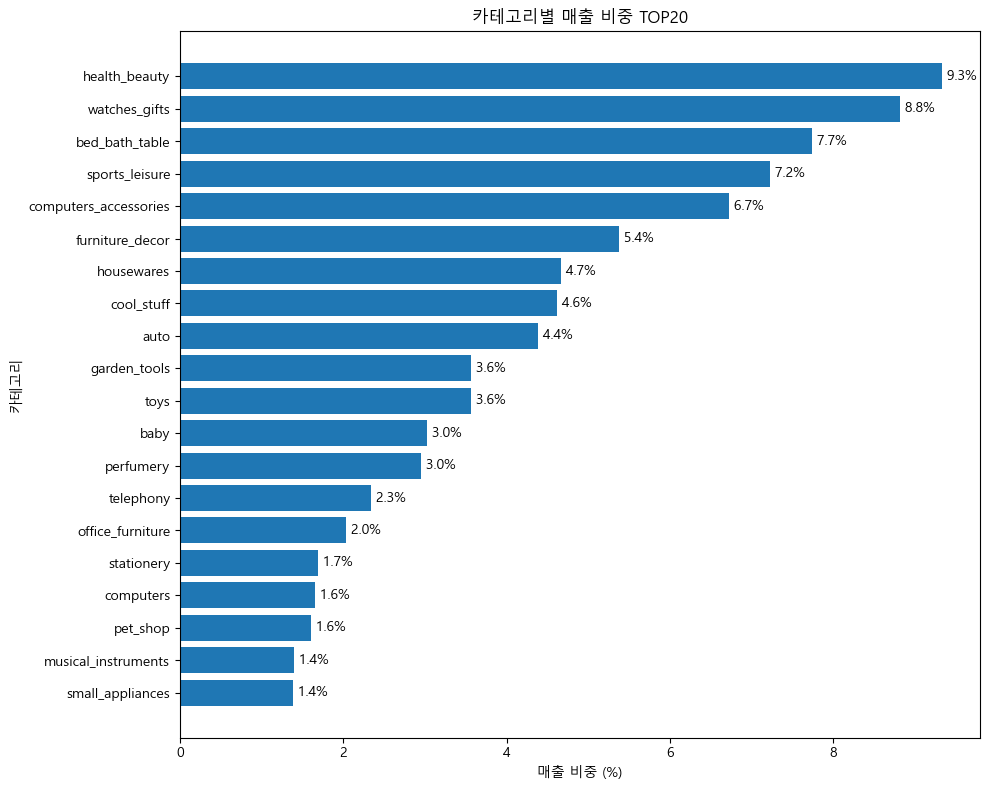

In [21]:
## 3. 포트폴리오용 시각화 5장 생성 및 저장
# 3-3. 카테고리별 매출 비중 TOP20
category_share_viz = category_revenue_share.head(20).copy()
category_share_viz = category_share_viz.sort_values(
    "revenue_share_pct",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    category_share_viz["product_category"],
    category_share_viz["revenue_share_pct"]
)

ax.set_title("카테고리별 매출 비중 TOP20")
ax.set_xlabel("매출 비중 (%)")
ax.set_ylabel("카테고리")

for i, value in enumerate(category_share_viz["revenue_share_pct"]):
    ax.text(
        value,
        i,
        f" {value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.savefig(IMAGE_DIR / "03_category_revenue_share_top20.png", dpi=DPI, bbox_inches="tight")
plt.show()

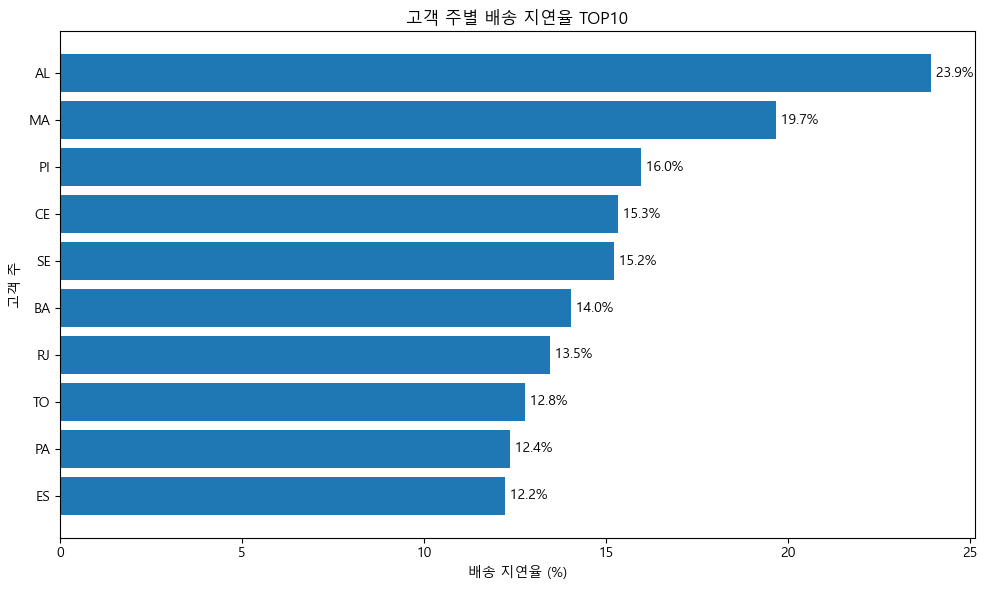

In [22]:
## 3. 포트폴리오용 시각화 5장 생성 및 저장
# 3-4. 고객 주별 배송 지연율 TOP10
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    delay_state_top10_viz["customer_state"],
    delay_state_top10_viz["delayed_order_rate_pct"]
)

ax.set_title("고객 주별 배송 지연율 TOP10")
ax.set_xlabel("배송 지연율 (%)")
ax.set_ylabel("고객 주")

for i, value in enumerate(delay_state_top10_viz["delayed_order_rate_pct"]):
    ax.text(
        value,
        i,
        f" {value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.savefig(IMAGE_DIR / "04_delay_rate_by_state.png", dpi=DPI, bbox_inches="tight")
plt.show()

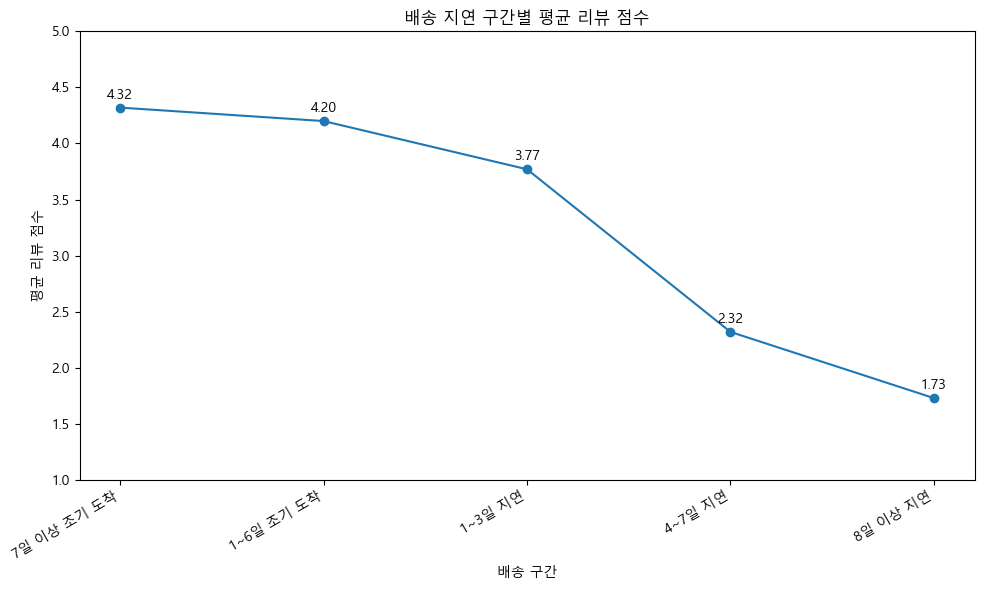

In [23]:
## 3. 포트폴리오용 시각화 5장 생성 및 저장
# 3-5. 배송 지연 구간별 평균 리뷰 점수
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    review_delay_viz["delay_group_label"],
    review_delay_viz["avg_review_score"],
    marker="o"
)

ax.set_title("배송 지연 구간별 평균 리뷰 점수")
ax.set_xlabel("배송 구간")
ax.set_ylabel("평균 리뷰 점수")
ax.set_ylim(1, 5)

for x, y in zip(review_delay_viz["delay_group_label"], review_delay_viz["avg_review_score"]):
    ax.text(
        x,
        y + 0.08,
        f"{y:.2f}",
        ha="center"
    )

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "05_review_score_by_delay_group.png", dpi=DPI, bbox_inches="tight")
plt.show()

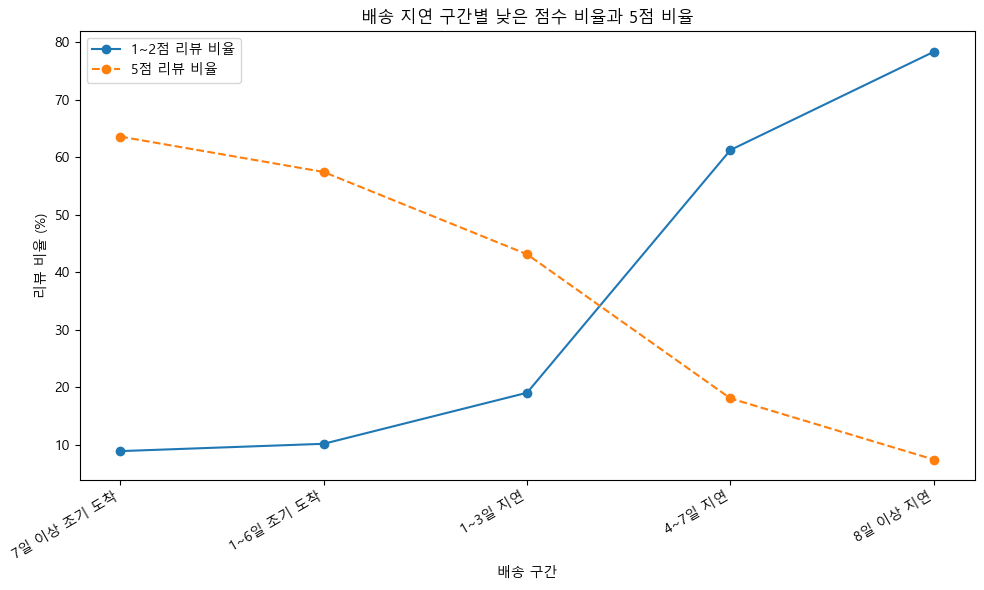

In [24]:
## 3. 포트폴리오용 시각화 5장 생성 및 저장
# 3-6. 배송 지연 구간별 낮은 점수 비율과 5점 비율
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    review_delay_viz["delay_group_label"],
    review_delay_viz["low_score_rate_pct"],
    marker="o",
    label="1~2점 리뷰 비율"
)

ax.plot(
    review_delay_viz["delay_group_label"],
    review_delay_viz["five_star_rate_pct"],
    marker="o",
    linestyle="--",
    label="5점 리뷰 비율"
)

ax.set_title("배송 지연 구간별 낮은 점수 비율과 5점 비율")
ax.set_xlabel("배송 구간")
ax.set_ylabel("리뷰 비율 (%)")
ax.legend()

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "06_review_score_distribution_by_delay.png", dpi=DPI, bbox_inches="tight")
plt.show()

In [25]:
## 4. 생성 이미지 목록 확인
image_files = sorted(IMAGE_DIR.glob("*.png"))

print(f"생성된 이미지 수: {len(image_files)}")
for image_file in image_files:
    print(image_file.name)

생성된 이미지 수: 6
01_monthly_orders_revenue.png
02_top_categories_revenue.png
03_category_revenue_share_top20.png
04_delay_rate_by_state.png
05_review_score_by_delay_group.png
06_review_score_distribution_by_delay.png
